<h2 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:center;
">
    SafeGuard Ag (Crop yield Prediction)
</h2>

### Project Overview 
This notebook aims to predict crop yield based on environmental and agricultural factors.

The workflow includes:
- Data loading and understanding
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature encoding and scaling
- Outlier/noise detection
- Model training using Artificial Neural Network (ANN)
- Model evaluation and comparison

### Objective
Build a regression model capable of predicting crop yield (tons per hectare).

<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    1. Import Required Libraries
</h3>

In this section, we import the libraries required for:
- Data manipulation
- Data visualization
- Machine learning preprocessing
- Model building and evaluation

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ML 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

# another
import os
import time
import joblib
RANDOM_STATE = 42

<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    2. Loading Dataset
</h3>

- The dataset contains agricultural and environmental features used to predict crop yield.
- The first step is loading the dataset and checking its structure.

In [2]:
data= pd.read_csv("../data/crop_yield.csv")
print('Data Shape:')
print(f'Rows      : {data.shape[0]}')
print(f'Columns : {data.shape[1]}')

Data Shape:
Rows      : 1000000
Columns : 10


In [3]:
print('Column dtypes:')
print(data.dtypes)

Column dtypes:
Region                        str
Soil_Type                     str
Crop                          str
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition             str
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object


In [4]:
print('Missing Values:')
print(data.isna().sum())
print('Duplicates:', data.duplicated().sum())

Missing Values:
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64
Duplicates: 0


<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    3. Dataset Exploration
</h3>

Before building any model, we analyze the dataset to understand:

- Number of samples and features
- Data types
- Missing values
- Statistical distribution
- Unique values in categorical variables

In [5]:
data.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  str    
 1   Soil_Type               1000000 non-null  str    
 2   Crop                    1000000 non-null  str    
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  str    
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 82.0 MB


In [7]:
print('Descriptive Statistics:')
data.describe().T.style.background_gradient(cmap='RdPu')

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Rainfall_mm,1000000.000000,549.981901,259.851320,100.000896,324.891090,550.124061,774.738520,999.998098
Temperature_Celsius,1000000.000000,27.504965,7.220608,15.000034,21.254502,27.507365,33.753267,39.999997
Days_to_Harvest,1000000.000000,104.495025,25.953412,60.000000,82.000000,104.000000,127.000000,149.000000
Yield_tons_per_hectare,1000000.000000,4.649472,1.696572,-1.147613,3.417637,4.651808,5.879200,9.963372


In [8]:
print('Unique Values in Categorical Columns:')
for col in ['Region', 'Soil_Type', 'Crop', 'Weather_Condition', 'Fertilizer_Used', 'Irrigation_Used']:
    values = data[col].unique()

    print(f"{col:<25} → {list(values)}")

Unique Values in Categorical Columns:
Region                    → ['West', 'South', 'North', 'East']
Soil_Type                 → ['Sandy', 'Clay', 'Loam', 'Silt', 'Peaty', 'Chalky']
Crop                      → ['Cotton', 'Rice', 'Barley', 'Soybean', 'Wheat', 'Maize']
Weather_Condition         → ['Cloudy', 'Rainy', 'Sunny']
Fertilizer_Used           → [False, True]
Irrigation_Used           → [True, False]


In [9]:
def find_outliers(data, col_name):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[(data < lower) | (data > upper)]

    print(f"{col_name:<30} | lower = {lower:10.2f}  upper = {upper:10.2f} | outliers = {len(outliers):,}")

    return outliers

print("Outlier Analysis")
print("=" * 60)
for col in ['Temperature_Celsius', 'Rainfall_mm', 'Days_to_Harvest', 'Yield_tons_per_hectare']:
    find_outliers(data[col], col)

Outlier Analysis
Temperature_Celsius            | lower =       2.51  upper =      52.50 | outliers = 0
Rainfall_mm                    | lower =    -349.88  upper =    1449.51 | outliers = 0
Days_to_Harvest                | lower =      14.50  upper =     194.50 | outliers = 0
Yield_tons_per_hectare         | lower =      -0.27  upper =       9.57 | outliers = 84


In [10]:
data["Yield_tons_per_hectare"].describe()

count    1000000.000000
mean           4.649472
std            1.696572
min           -1.147613
25%            3.417637
50%            4.651808
75%            5.879200
max            9.963372
Name: Yield_tons_per_hectare, dtype: float64

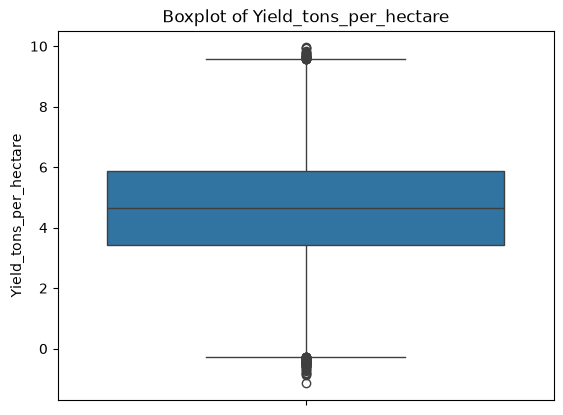

In [11]:
plt.figure()

sns.boxplot(
    data["Yield_tons_per_hectare"]
)
plt.title("Boxplot of Yield_tons_per_hectare")
plt.show()

<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    4. Data Cleaning
</h3>
In this stage, we handle data quality issues by:

- Removing invalid values
- Detecting possible outliers
- Reducing noise that may negatively affect model performance

In [12]:
# Remove negative yields
data = data[data['Yield_tons_per_hectare'] >= 0].copy()
print(f'Dataset after removing negative yields: {data.shape[0]} rows')

Dataset after removing negative yields: 999769 rows


In [13]:
data.shape

(999769, 10)

<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    5. Exploratory Data Analysis (EDA)
</h3>

EDA helps us discover relationships between crop yield and different factors.
We analyze:
- Crop type impact
- Soil characteristics
- Weather conditions
- Rainfall and other numerical features
- Feature relationships

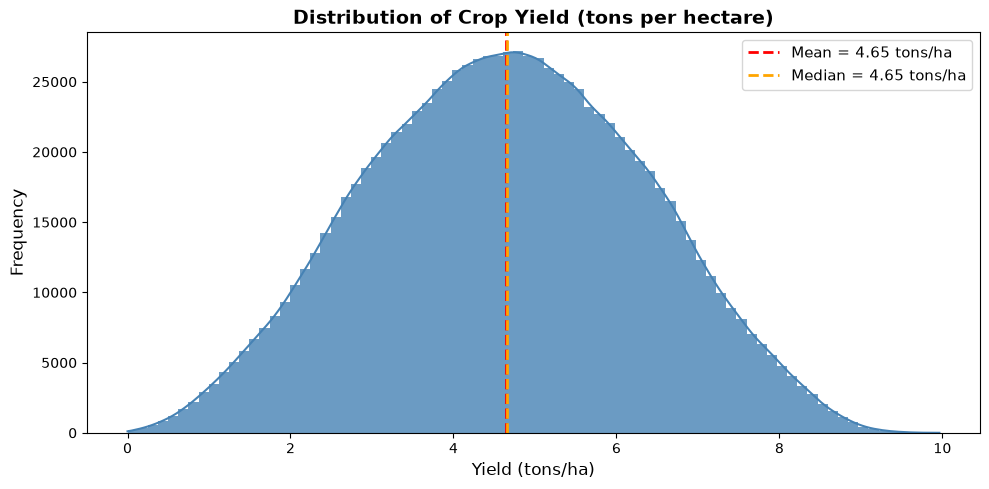

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data['Yield_tons_per_hectare'],
    bins=80,
    kde=True, # Add a Kernel Density Estimate (KDE) curve
    color='steelblue',
    edgecolor='none',
    alpha=0.8
    )

# Add vertical lines for mean and median
plt.axvline(
    data['Yield_tons_per_hectare'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f"Mean = {data['Yield_tons_per_hectare'].mean():.2f} tons/ha"
    )

plt.axvline(
    data['Yield_tons_per_hectare'].median(),
    color='orange',
    linestyle='--',
    lw=2,
    label=f"Median = {data['Yield_tons_per_hectare'].median():.2f} tons/ha"
    )

plt.title(
    'Distribution of Crop Yield (tons per hectare)',
    fontsize=14,
    fontweight='bold'
    )

plt.xlabel('Yield (tons/ha)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
os.makedirs("../graphs", exist_ok=True)

plt.savefig(
    "../graphs/plot_01_yield_distribution.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

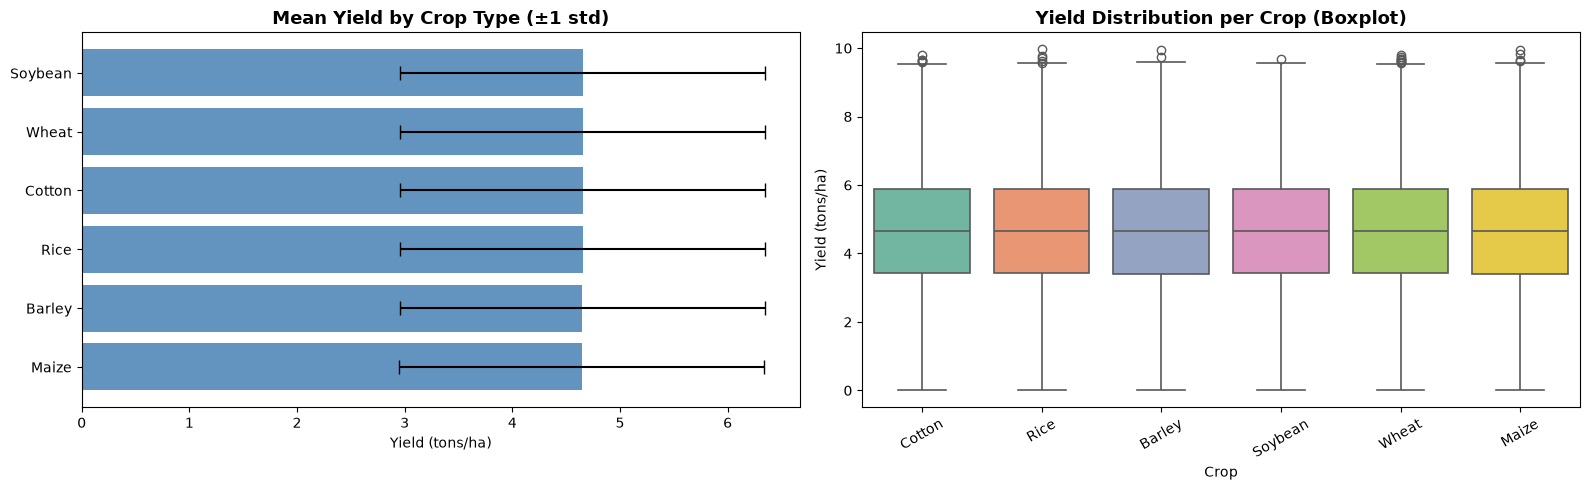

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

crop_means = data.groupby('Crop')['Yield_tons_per_hectare'].agg(['mean','std']).sort_values('mean')
axes[0].barh(
    crop_means.index,
    crop_means['mean'],
    xerr=crop_means['std'],
    color='steelblue',
    error_kw=dict(
        capsize=5,
        elinewidth=1.5),
    alpha=0.85)
axes[0].set_title('Mean Yield by Crop Type (±1 std)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Yield (tons/ha)')

sns.boxplot(x='Crop', y='Yield_tons_per_hectare', data=data,
            palette='Set2', linewidth=1.2, ax=axes[1])
axes[1].set_title('Yield Distribution per Crop (Boxplot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Crop')
axes[1].set_ylabel('Yield (tons/ha)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../graphs/plot_02_yield_by_crop.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print(crop_means)

             mean       std
Crop                       
Maize    4.642513  1.694621
Barley   4.648864  1.696475
Rice     4.651849  1.696802
Cotton   4.651918  1.694011
Wheat    4.653722  1.693550
Soybean  4.654701  1.695533


Yield by Region:
                         mean                 median                    min  \
       Yield_tons_per_hectare Yield_tons_per_hectare Yield_tons_per_hectare   
Region                                                                        
East                 4.646696               4.650415               0.000411   
North                4.655298               4.659948               0.005619   
South                4.649869               4.647228               0.000672   
West                 4.650497               4.651797               0.002143   

                          max                  count  
       Yield_tons_per_hectare Yield_tons_per_hectare  
Region                                                
East                 9.802534                 249642  
North                9.949207                 250112  
South                9.963372                 250001  
West                 9.952983                 250014  


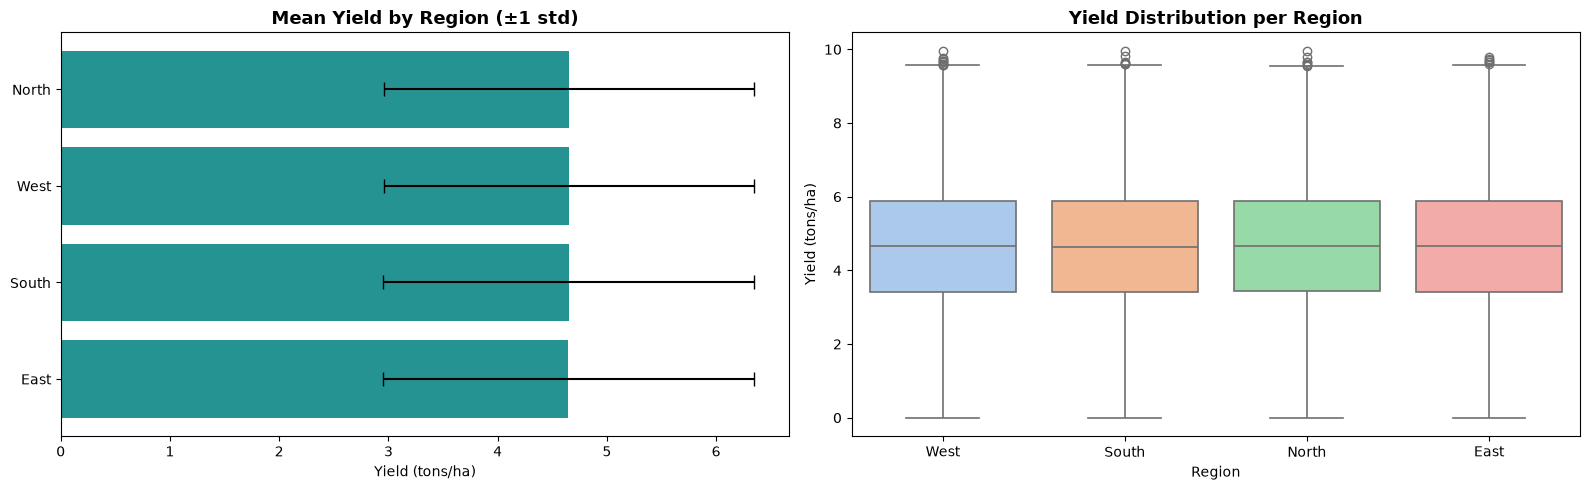

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

region_pivot = data.pivot_table(index='Region',
                            values='Yield_tons_per_hectare',
                            aggfunc=['mean','median','min','max','count'])
print('Yield by Region:')
print(region_pivot)

region_means = data.groupby('Region')['Yield_tons_per_hectare'].agg(['mean','std']).sort_values('mean')
axes[0].barh(region_means.index, region_means['mean'], xerr=region_means['std'],
            color='teal', error_kw=dict(capsize=5), alpha=0.85)
axes[0].set_title('Mean Yield by Region (±1 std)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Yield (tons/ha)')

sns.boxplot(x='Region', y='Yield_tons_per_hectare', data=data,
            palette='pastel', linewidth=1.2, ax=axes[1])
axes[1].set_title('Yield Distribution per Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Yield (tons/ha)')

plt.tight_layout()
plt.savefig('../graphs/plot_03_yield_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

By Fertilizer:
                     mean    median       min       max
Fertilizer_Used                                        
False            3.901402  3.904919  0.000411  8.683593
True             5.399616  5.398603  0.498752  9.963372

By Irrigation:
                     mean    median       min       max
Irrigation_Used                                        
False            4.051897  4.052659  0.000411  8.986859
True             5.250231  5.250169  0.371804  9.963372


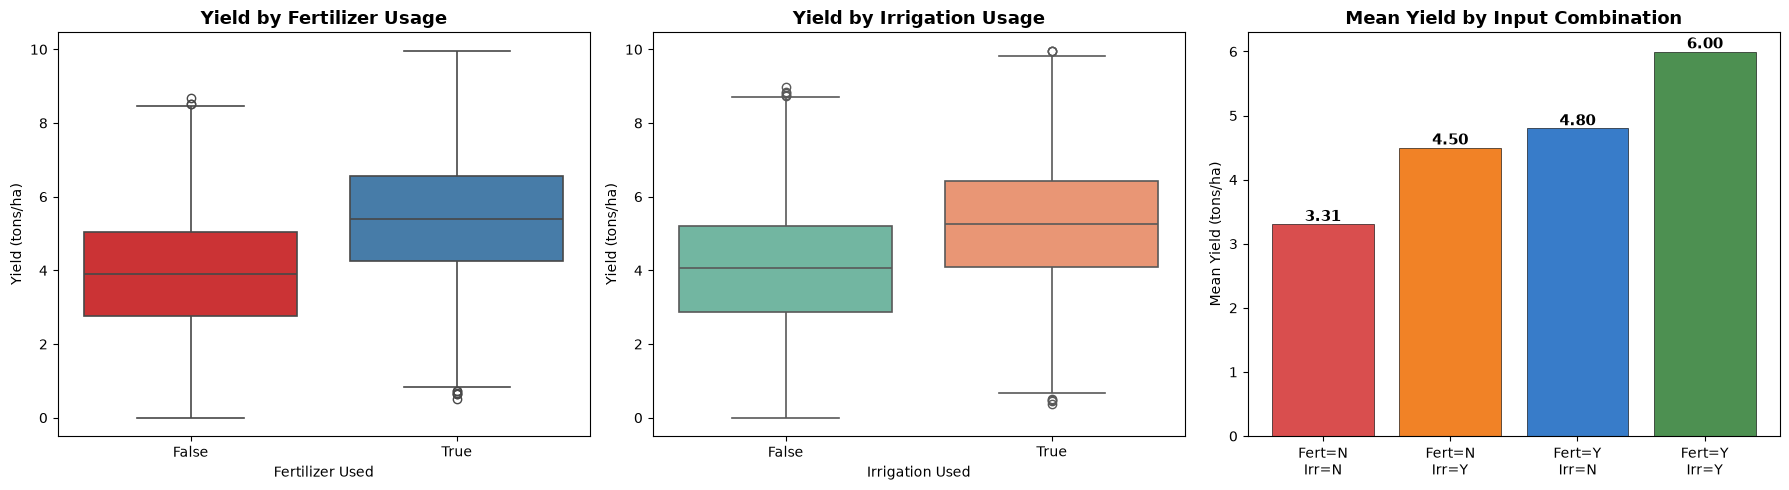

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fertilizer
by_fert = data.groupby('Fertilizer_Used')['Yield_tons_per_hectare'].agg(['mean','median','min','max'])
print('By Fertilizer:')
print(by_fert)
sns.boxplot(x='Fertilizer_Used', y='Yield_tons_per_hectare', data=data,
            palette='Set1', ax=axes[0], linewidth=1.2)
axes[0].set_title('Yield by Fertilizer Usage', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fertilizer Used')
axes[0].set_ylabel('Yield (tons/ha)')

# Irrigation
by_irr = data.groupby('Irrigation_Used')['Yield_tons_per_hectare'].agg(['mean','median','min','max'])
print('\nBy Irrigation:')
print(by_irr)
sns.boxplot(x='Irrigation_Used', y='Yield_tons_per_hectare', data=data,
            palette='Set2', ax=axes[1], linewidth=1.2)
axes[1].set_title('Yield by Irrigation Usage', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Irrigation Used')
axes[1].set_ylabel('Yield (tons/ha)')

# Combined
by_both = data.groupby(['Fertilizer_Used','Irrigation_Used'])['Yield_tons_per_hectare'].mean().reset_index()
by_both['label'] = by_both.apply(lambda r: f"Fert={'Y' if r.Fertilizer_Used else 'N'}\nIrr={'Y' if r.Irrigation_Used else 'N'}", axis=1)
axes[2].bar(by_both['label'], by_both['Yield_tons_per_hectare'],
            color=['#d32f2f','#ef6c00','#1565c0','#2e7d32'], alpha=0.85, edgecolor='black', lw=0.5)
axes[2].set_title('Mean Yield by Input Combination', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Mean Yield (tons/ha)')
for i, v in enumerate(by_both['Yield_tons_per_hectare']):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../graphs/plot_04_fertilizer_irrigation.png', dpi=150, bbox_inches='tight')
plt.show()

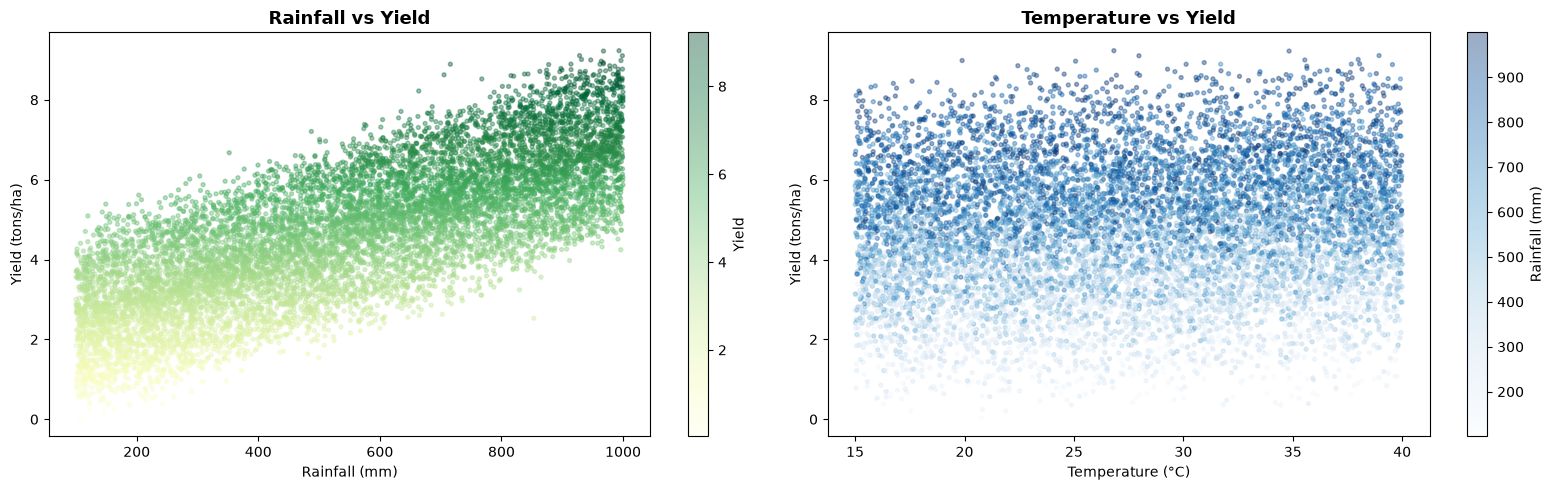

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample = data.sample(10000, random_state=42)
scatter1 = axes[0].scatter(sample['Rainfall_mm'], sample['Yield_tons_per_hectare'],
                        c=sample['Yield_tons_per_hectare'], cmap='YlGn',
                        alpha=0.4, s=8)
plt.colorbar(scatter1, ax=axes[0], label='Yield')
axes[0].set_title('Rainfall vs Yield', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Yield (tons/ha)')

scatter2 = axes[1].scatter(sample['Temperature_Celsius'], sample['Yield_tons_per_hectare'],
                        c=sample['Rainfall_mm'], cmap='Blues',
                        alpha=0.4, s=8)
plt.colorbar(scatter2, ax=axes[1], label='Rainfall (mm)')
axes[1].set_title('Temperature vs Yield', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Yield (tons/ha)')

plt.tight_layout()
plt.savefig('../graphs/plot_05_rainfall_temp_yield.png', dpi=150, bbox_inches='tight')
plt.show()

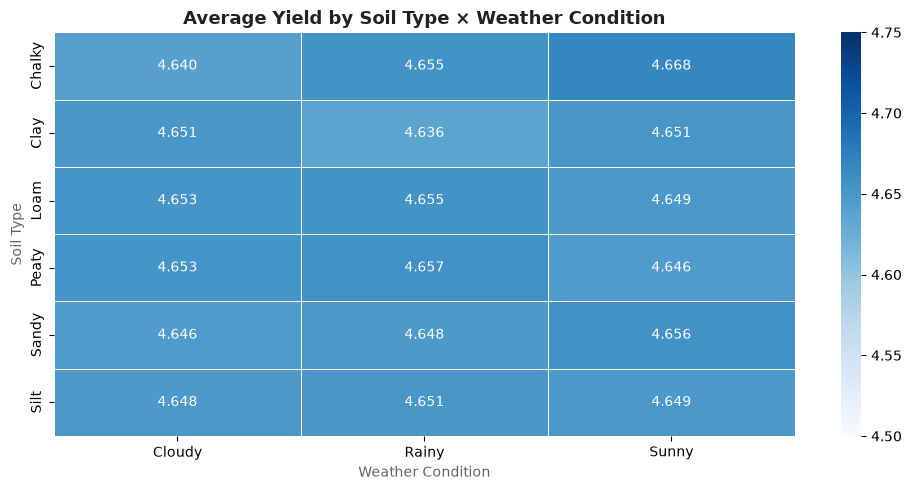

In [20]:
pivot_soil_weather = data.pivot_table(
    values='Yield_tons_per_hectare',
    index='Soil_Type',
    columns='Weather_Condition',
    aggfunc='mean'
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot_soil_weather,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    vmin=4.5,
    vmax=4.75
)

plt.title(
    'Average Yield by Soil Type × Weather Condition',
    fontsize=13,
    fontweight='bold',
    color='#202124'
)

plt.xlabel('Weather Condition', color='#5F6368')
plt.ylabel('Soil Type', color='#5F6368')

plt.tight_layout()

plt.savefig('../graphs/plot_06_soil_weather_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

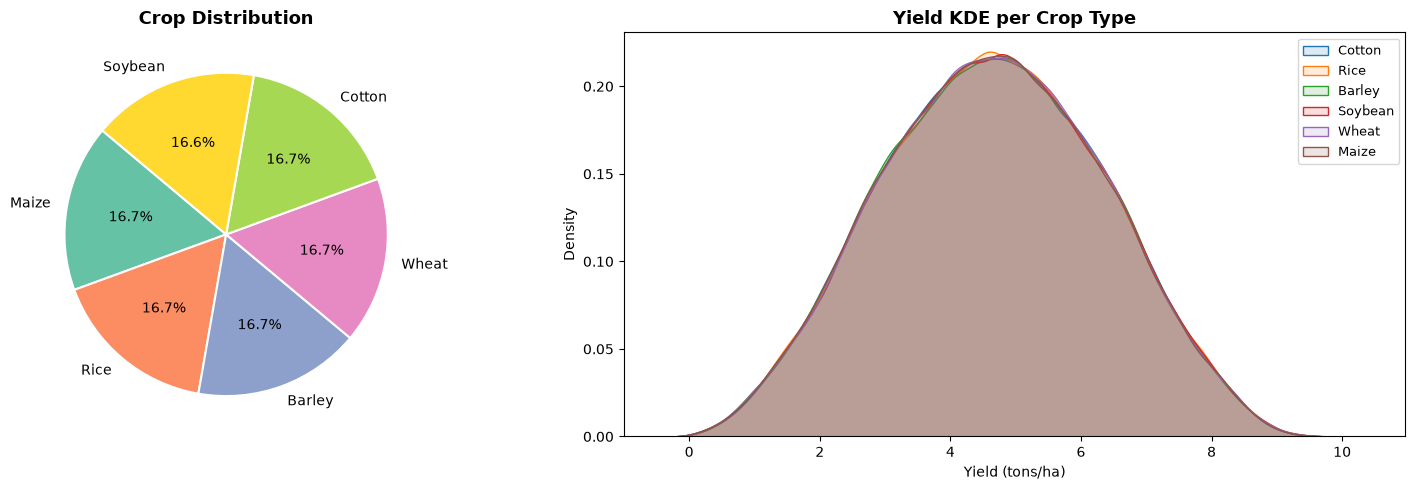

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

crop_counts = data['Crop'].value_counts()
axes[0].pie(crop_counts, labels=crop_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(crop_counts)),
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Crop Distribution', fontsize=13, fontweight='bold')

for crop in data['Crop'].unique():
    sns.kdeplot(data[data['Crop'] == crop]['Yield_tons_per_hectare'],
                label=crop, ax=axes[1], fill=True, alpha=0.15)
axes[1].set_title('Yield KDE per Crop Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Yield (tons/ha)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../graphs/plot_07_crop_distribution_kde.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
bool_cols = ['Fertilizer_Used', 'Irrigation_Used']
data[bool_cols] = data[bool_cols].astype(int)
print(data[bool_cols].head())

   Fertilizer_Used  Irrigation_Used
0                0                1
1                1                1
2                0                0
3                0                1
4                1                1


In [23]:
data.info()

<class 'pandas.DataFrame'>
Index: 999769 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Region                  999769 non-null  str    
 1   Soil_Type               999769 non-null  str    
 2   Crop                    999769 non-null  str    
 3   Rainfall_mm             999769 non-null  float64
 4   Temperature_Celsius     999769 non-null  float64
 5   Fertilizer_Used         999769 non-null  int32  
 6   Irrigation_Used         999769 non-null  int32  
 7   Weather_Condition       999769 non-null  str    
 8   Days_to_Harvest         999769 non-null  int64  
 9   Yield_tons_per_hectare  999769 non-null  float64
dtypes: float64(3), int32(2), int64(1), str(4)
memory usage: 95.8 MB


In [24]:
data.sample(5)

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
759077,East,Chalky,Maize,568.346321,21.817252,1,0,Sunny,99,4.298509
875704,East,Peaty,Cotton,366.321815,39.339284,0,0,Sunny,95,2.270891
553181,East,Peaty,Cotton,218.910263,39.217948,1,0,Sunny,145,3.934799
638906,North,Silt,Rice,630.933518,32.660707,1,1,Cloudy,95,6.658755
716873,South,Clay,Barley,546.950890,33.573123,1,0,Rainy,147,4.846852


In [25]:
data.columns

Index(['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius',
       'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition',
       'Days_to_Harvest', 'Yield_tons_per_hectare'],
      dtype='str')

In [26]:
cols = [
    'Rainfall_mm',
    'Temperature_Celsius',
    'Fertilizer_Used',
    'Irrigation_Used',
    'Days_to_Harvest',
    'Yield_tons_per_hectare'
]

df = data[cols]

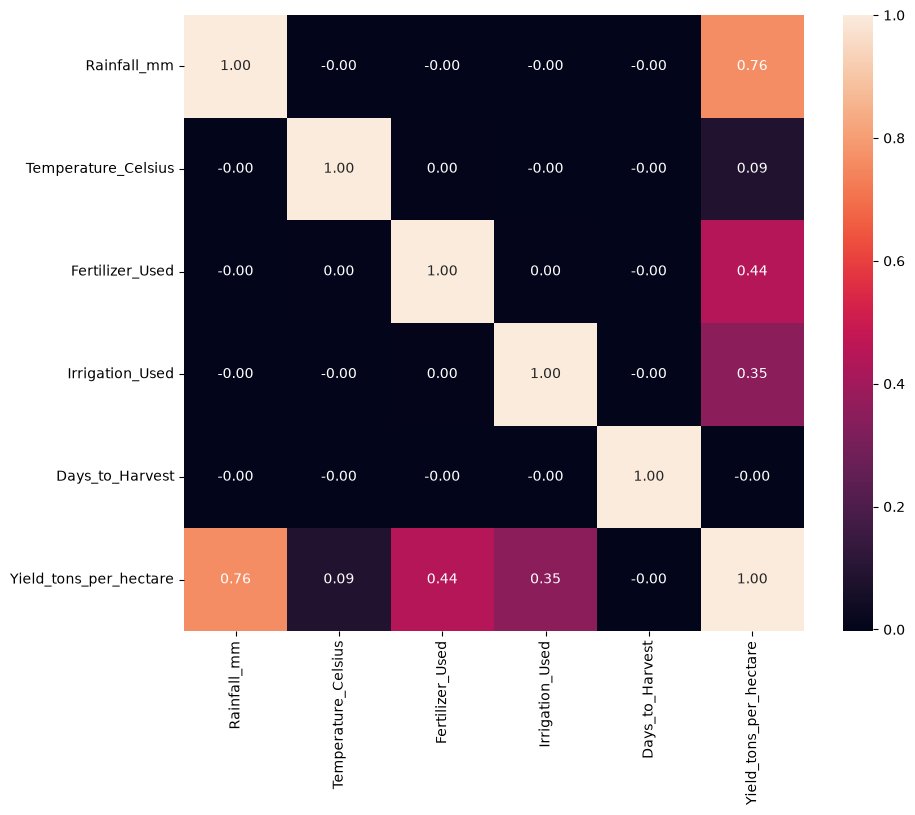

Yield_tons_per_hectare    1.000000
Rainfall_mm               0.764512
Fertilizer_Used           0.441908
Irrigation_Used           0.353456
Temperature_Celsius       0.085213
Days_to_Harvest          -0.002605
Name: Yield_tons_per_hectare, dtype: float64


In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True),annot=True, fmt=".2f")
plt.show()
print(df.corr()["Yield_tons_per_hectare"].sort_values(ascending=False))

<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    6. Feature Encoding
</h3>

- Machine learning models require numerical inputs.

- Categorical features are transformed into numerical representations using encoding techniques.

In [28]:
crop_encoder = LabelEncoder()
region_encoder = LabelEncoder()
soil_encoder = LabelEncoder()
weather_encoder = LabelEncoder()

df_enc = data.copy()

df_enc["Crop"] = crop_encoder.fit_transform(df_enc["Crop"])
df_enc["Region"] = region_encoder.fit_transform(df_enc["Region"])
df_enc["Soil_Type"] = soil_encoder.fit_transform(df_enc["Soil_Type"])
df_enc["Weather_Condition"] = weather_encoder.fit_transform(df_enc["Weather_Condition"])

df_enc["Fertilizer_Used"] = df_enc["Fertilizer_Used"].astype(int)
df_enc["Irrigation_Used"] = df_enc["Irrigation_Used"].astype(int)

In [29]:
df_enc.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,3,4,1,897.077239,27.676966,0,1,0,122,6.555816
1,2,1,3,992.673282,18.026142,1,1,1,140,8.527341
2,1,2,0,147.998025,29.794042,0,0,2,106,1.127443
3,1,4,4,986.866331,16.644190,0,1,1,146,6.517573
4,2,5,5,730.379174,31.620687,1,1,0,110,7.248251


<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    7. Feature Selection
</h3>

The dataset is divided into:

- X: input features used for prediction
- y: target variable (crop yield)

The goal is to learn the relationship between input variables and crop productivity.

In [30]:
X = df_enc.drop('Yield_tons_per_hectare', axis=1)
y = df_enc['Yield_tons_per_hectare']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Standard scale for algorithms that need it
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

print(f'Train: {X_tr.shape[0]:,} rows  |  Test: {X_te.shape[0]:,} rows')
print(f'Features: {X.shape[1]}')

Train: 799,815 rows  |  Test: 199,954 rows
Features: 9


<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    8. Noise Detection and Data Refinement
</h3>

- A noise detection approach is applied to identify samples that may negatively affect model learning.

- Cleaning noisy samples helps improve the model's ability to generalize.

In [31]:
#  Step 1: Train noise-detection model on full data 
print('Training noise detection model...')
m_noise = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                            tree_method='hist', random_state=RANDOM_STATE)
m_noise.fit(X, y, verbose=False)

residuals_all = np.abs(y.values - m_noise.predict(X))
threshold_10  = np.percentile(residuals_all, 90)

print(f'Residual stats:')
print(f'  Mean   : {residuals_all.mean():.4f}')
print(f'  Std    : {residuals_all.std():.4f}')
print(f'  90th %-ile threshold : {threshold_10:.4f} tons/ha')
print(f'  Rows to remove (top 10%): {(residuals_all > threshold_10).sum():,}')
print(f'  Rows to keep (90%)      : {(residuals_all <= threshold_10).sum():,}')

Training noise detection model...
Residual stats:
  Mean   : 0.3972
  Std    : 0.3000
  90th %-ile threshold : 0.8186 tons/ha
  Rows to remove (top 10%): 99,977
  Rows to keep (90%)      : 899,792


In [32]:
# Step 2: Apply 10% residual cleaning 
keep_mask  = residuals_all <= threshold_10
df_clean   = df_enc[keep_mask].reset_index(drop=True)

X_clean = df_clean.drop('Yield_tons_per_hectare', axis=1)
y_clean = df_clean['Yield_tons_per_hectare']

print(f'Original rows : {len(df_enc):,}')
print(f'Removed rows  : {len(df_enc) - len(df_clean):,}  (10%)')
print(f'Cleaned rows  : {len(df_clean):,}')
print(f'\nCleaned target stats:')
print(y_clean.describe())

Original rows : 999,769
Removed rows  : 99,977  (10%)
Cleaned rows  : 899,792

Cleaned target stats:
count    899792.000000
mean          4.649343
std           1.668655
min           0.007505
25%           3.430566
50%           4.652208
75%           5.866008
max           9.268604
Name: Yield_tons_per_hectare, dtype: float64


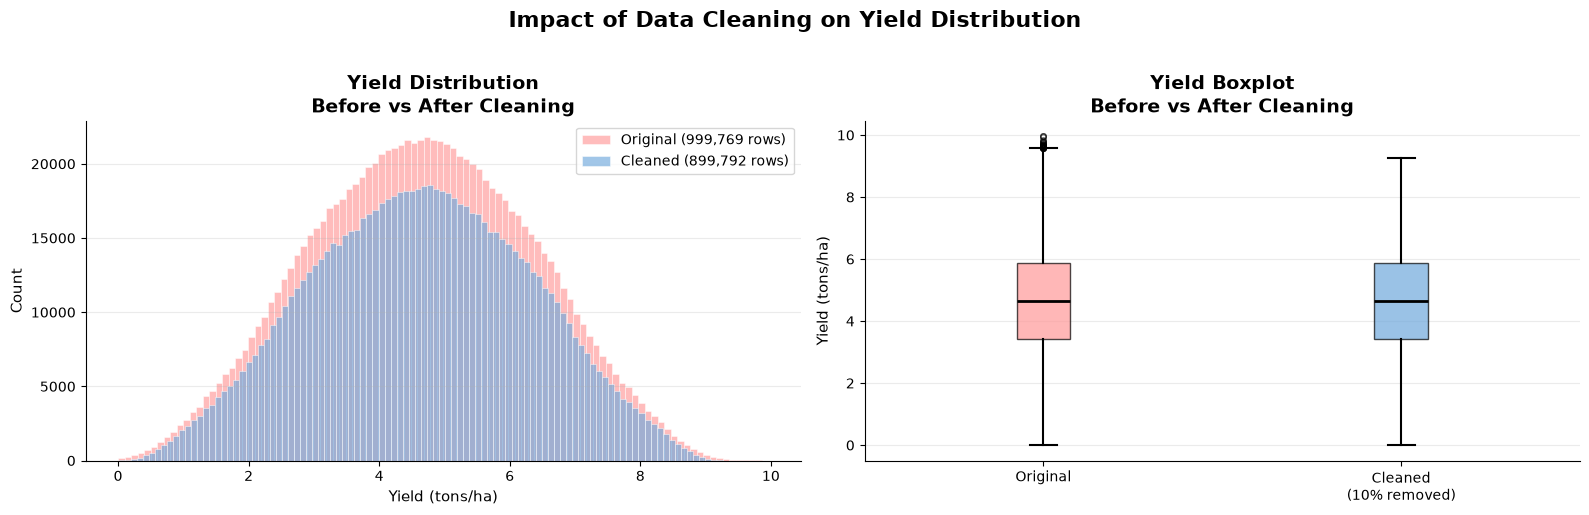

In [33]:
# Plot 9: Before vs After cleaning 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(y, bins=100, color='#FF9999', alpha=0.65, 
            edgecolor='white', linewidth=0.5,
            label=f'Original ({len(y):,} rows)')

axes[0].hist(y_clean, bins=100, color='#6FA8DC', alpha=0.65, 
            edgecolor='white', linewidth=0.5,
            label=f'Cleaned ({len(y_clean):,} rows)')

axes[0].set_title('Yield Distribution\nBefore vs After Cleaning',
                fontsize=14, fontweight='bold')

axes[0].set_xlabel('Yield (tons/ha)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

axes[0].legend(fontsize=10, frameon=True)
axes[0].grid(axis='y', alpha=0.25)


# Boxplot
box = axes[1].boxplot(
    [y.values, y_clean.values],
    tick_labels=['Original', 'Cleaned\n(10% removed)'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5), # caps on whiskers
    flierprops=dict(marker='o', markersize=4, alpha=0.5) # outliers as small circles
)

# Different colors for boxes
colors = ['#FF9999', '#6FA8DC']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Yield Boxplot\nBefore vs After Cleaning',
                fontsize=14, fontweight='bold')

axes[1].set_ylabel('Yield (tons/ha)', fontsize=11)
axes[1].grid(axis='y', alpha=0.25)


# General styling
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=10)

plt.suptitle('Impact of Data Cleaning on Yield Distribution',
            fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../graphs/plot_09_before_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    9. Dataset Splitting after removing noise
</h3>
The dataset is divided into:

- Training set: used to learn model parameters
- Testing set: used to evaluate performance on unseen data

In [34]:
# Train-test split 
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Scale 
sc2 = StandardScaler()
X_tr2_sc = sc2.fit_transform(X_tr2)
X_te2_sc = sc2.transform(X_te2)

print(f'Train : {X_tr2.shape[0]:,} rows')
print(f'Test  : {X_te2.shape[0]:,} rows')
print(f'Features: {X_clean.shape[1]}')

Train : 719,833 rows
Test  : 179,959 rows
Features: 9


<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    10. Artificial Neural Network (ANN) Model
</h3>
An ANN is used for regression prediction.

Architecture:
- Input layer receives feature values
- Hidden layers learn complex relationships
- Output layer predicts crop yield

The model is trained by minimizing prediction error using backpropagation.

In [35]:
input_dim = X_clean.shape[1]

def build_ann(input_dim):

    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.20),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.15),

        Dense(32, activation='relu'),
        BatchNormalization(),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model


ann_model = build_ann(input_dim)
ann_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               1280      
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 64)                

<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    11. Model Training & Compiling
</h3>

The ANN model is trained using:
- Optimizer: controls weight updates
- Loss function: measures prediction error
- Learning rate scheduling: improves convergence

In [36]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

In [37]:
print('Starting ANN training...')
t_start = time.time()
NUM_EPOCHS =60
history = ann_model.fit(
    X_tr2_sc,
    y_tr2,
    validation_data=(X_te2_sc, y_te2),
    epochs=NUM_EPOCHS,
    batch_size=2048,
    callbacks=[lr_scheduler],
    verbose=1
)

print(f'\nTraining complete in {time.time()-t_start:.1f}s')
train_losses = history.history['loss']
val_losses = history.history['val_loss']

Starting ANN training...
Epoch 1/60


352/352 [==============================] - 7s 13ms/step - loss: 7.5350 - mae: 2.2202 - val_loss: 0.1930 - val_mae: 0.3603 - lr: 0.0010
Epoch 2/60
352/352 [==============================] - 4s 13ms/step - loss: 0.2390 - mae: 0.3963 - val_loss: 0.1685 - val_mae: 0.3398 - lr: 0.0010
Epoch 3/60
352/352 [==============================] - 5s 13ms/step - loss: 0.2066 - mae: 0.3712 - val_loss: 0.1621 - val_mae: 0.3343 - lr: 0.0010
Epoch 4/60
352/352 [==============================] - 4s 12ms/step - loss: 0.1943 - mae: 0.3611 - val_loss: 0.1621 - val_mae: 0.3343 - lr: 0.0010
Epoch 5/60
352/352 [==============================] - 4s 12ms/step - loss: 0.1873 - mae: 0.3555 - val_loss: 0.1625 - val_mae: 0.3347 - lr: 0.0010
Epoch 6/60
352/352 [==============================] - 4s 13ms/step - loss: 0.1830 - mae: 0.3519 - val_loss: 0.1728 - val_mae: 0.3434 - lr: 0.0010
Epoch 7/60
352/352 [==============================] - 4s 12ms/step - loss: 0.1789 - mae: 0.3486 -

<h3 style="
    background-color:#F8B4C4; 
    font-family:Georgia; 
    color:#555; 
    padding:10px; 
    border-radius:6px;
    text-align:left;
">
    12. Model Evaluation
</h3>

The model performance is measured using regression metrics:

- R² Score: measures explained variance
- RMSE: measures average prediction error
- MAE: measures absolute prediction error

In [38]:
y_pred = ann_model.predict(X_te2_sc)

ann_r2 = r2_score(y_te2, y_pred)
ann_rmse = np.sqrt(mean_squared_error(y_te2, y_pred))
ann_mae = mean_absolute_error(y_te2, y_pred)

print(f'R²   : {ann_r2:.4f}')
print(f'RMSE : {ann_rmse:.4f}')
print(f'MAE  : {ann_mae:.4f}')

5624/5624 [==============================] - 9s 2ms/step
R²   : 0.9417
RMSE : 0.4024
MAE  : 0.3340


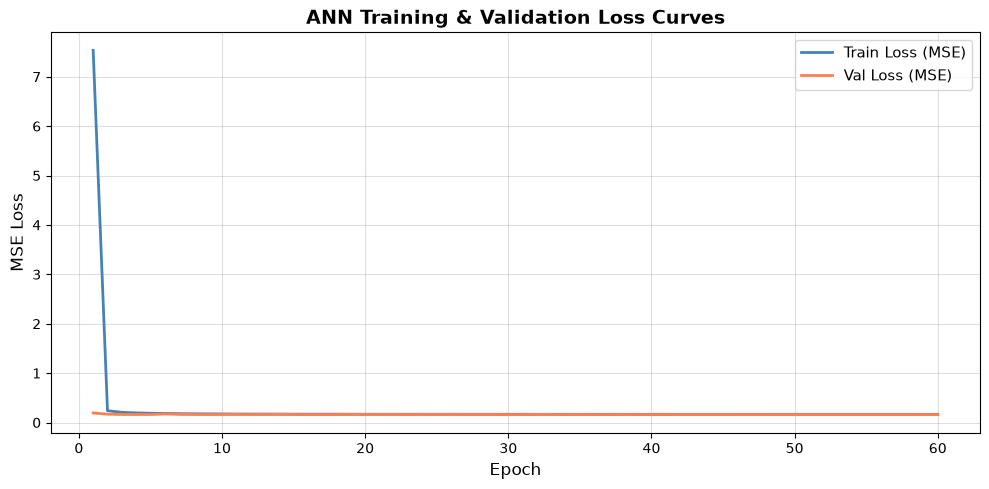

In [39]:
# Plot 10: Training curves 
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label='Train Loss (MSE)',color='steelblue', lw=2)
plt.plot(range(1, NUM_EPOCHS+1), val_losses, label='Val Loss (MSE)', color='coral', lw=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('ANN Training & Validation Loss Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('../graphs/plot_10_ann_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ANN Evaluation (TensorFlow) 
y_ann_pred = ann_model.predict(X_te2_sc).flatten()
ann_r2   = r2_score(y_te2, y_ann_pred)
ann_rmse = np.sqrt(mean_squared_error(y_te2, y_ann_pred))
ann_mae  = mean_absolute_error(y_te2, y_ann_pred)
residuals_ann = y_te2.values - y_ann_pred

print()
print('ANN Final Evaluation Metrics:')
print('=' * 30)
print(f'R² Score     : {ann_r2:.4f}')
print(f'RMSE         : {ann_rmse:.4f} tons/ha')
print(f'MAE          : {ann_mae:.4f} tons/ha')
print(f'Residual Std : {residuals_ann.std():.4f}')

5624/5624 [==============================] - 12s 2ms/step

ANN Final Evaluation Metrics:
R² Score     : 0.9417
RMSE         : 0.4024 tons/ha
MAE          : 0.3340 tons/ha
Residual Std : 0.4014


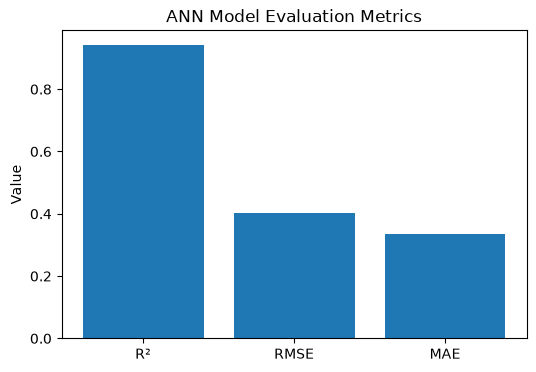

In [41]:
# Plot 11: Model Final Comparison
metrics = {
    'R²': ann_r2,
    'RMSE': ann_rmse,
    'MAE': ann_mae
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values())

plt.title("ANN Model Evaluation Metrics")
plt.ylabel("Value")
plt.savefig('../graphs/plot_11_ann_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

<h3 style="
    background-color:#F8B4C4;
    font-family:Georgia;
    color:#555;
    padding:10px;
    border-radius:6px;
    text-align:left;
">
    13. Model Saving
</h3>

After validating the model performance and confirming its stability, the trained model and preprocessing objects are saved for future inference and deployment.

The following artifacts are stored:

- Trained ANN Model (.keras)
- Standard Scaler (.pkl)
- Label Encoders (.pkl)

Saving these components ensures consistent preprocessing and prediction during deployment.

In [42]:
os.makedirs("../models", exist_ok=True)

# Save ANN model
ann_model.save("../models/crop_yield_ann.keras")
# ann_model.save("../models/crop_yield_ann.h5")
# joblib.dump(ann_model, '../models/crop_yield_model.pkl')

# Save scaler
joblib.dump(scaler, "../models/scaler.pkl")

# Save encoders
joblib.dump(crop_encoder, "../models/crop_encoder.pkl")
joblib.dump(region_encoder, "../models/region_encoder.pkl")
joblib.dump(soil_encoder, "../models/soil_encoder.pkl")
joblib.dump(weather_encoder, "../models/weather_encoder.pkl")

print("All models saved successfully!")

All models saved successfully!


<h3 style="
    background-color:#F8B4C4;
    font-family:Georgia;
    color:#555;
    padding:10px;
    border-radius:6px;
    text-align:left;
">
    14. Stability Analysis
</h3>

The stability of the proposed pipeline is assessed by repeating the training process using different random train-test splits.

The following metrics are analyzed across multiple runs:

- Mean R² Score
- Mean RMSE
- Mean MAE
- Standard Deviation (STD)

A low standard deviation indicates that the model is stable, robust, and capable of producing consistent predictions on unseen data.

In [43]:
NUM_RUNS = 5
results = []

for seed in range(NUM_RUNS):

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean,
        y_clean,
        test_size=0.2,
        random_state=seed
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = build_ann(input_dim)

    model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=NUM_EPOCHS,
        batch_size=2048,
        verbose=0
    )

    pred = model.predict(X_test, verbose=0).flatten()

    results.append({
        "Run": seed + 1,
        "R²": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

stability_df = pd.DataFrame(results)

display(stability_df)

print("\n========== Stability Summary ==========\n")

display(stability_df.describe().loc[['mean', 'std']])

,Run,R²,RMSE,MAE
0,1,0.943294,0.397114,0.330222
1,2,0.941896,0.401623,0.333207
2,3,0.943357,0.397232,0.330631
3,4,0.941861,0.402588,0.334345
4,5,0.940966,0.405185,0.335950



========== Stability Summary ==========



,Run,R²,RMSE,MAE
mean,3.000000,0.942275,0.400748,0.332871
std,1.581139,0.001029,0.003514,0.002439


# Conclusion

In this project, an ANN-based regression model was developed to predict crop yield.

The workflow included data exploration, preprocessing, noise reduction, model training, and evaluation.

The final model demonstrates the ability of machine learning techniques to support agricultural prediction tasks.